In [3]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import datetime as dt
from datetime import datetime
import os
import kagglehub

/Users/davidal-gurnawi/Documents/data_science/machine_learning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Change directory to the data location
os.chdir('../../ml_data')

# Read the data
df = pd.read_csv('credit_card_fraud_dataset.csv')
df

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0
...,...,...,...,...,...,...,...
99995,99996,2024-06-07 00:57:36.027591,1057.29,289,refund,San Antonio,0
99996,99997,2023-10-22 23:12:36.027594,297.25,745,refund,San Antonio,0
99997,99998,2024-05-31 19:27:36.027597,3448.56,690,purchase,San Antonio,0
99998,99999,2024-10-18 09:43:36.027601,3750.79,644,purchase,Philadelphia,0


In [5]:
# Looking at each column we essentially have 5 dimensions to explore, for which to determine whether the features would be of interest
#  - Time and Date
#  - Amount
#  - Merchant ID 
#  - Transaction Type 
#  - Location

### Date and Time

In [6]:
# Let us first confirm the data type of the column
print(df.TransactionDate.dtype)

object


In [7]:
# This is an object format and not a datetime format, something which we will need to correct
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
print(df.TransactionDate.dtype)

datetime64[ns]


In [8]:
# Now let us break down the Transaction Date into its constituent components
df['Year'] = df.TransactionDate.dt.year
df['month'] = df.TransactionDate.dt.month 
df['day'] = df.TransactionDate.dt.day 
df['hour'] = df.TransactionDate.dt.hour
df.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud,Year,month,day,hour
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0,2024,4,3,14
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0,2024,3,19,13
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0,2024,1,8,10
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0,2024,4,13,23
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0,2024,7,12,18


In [9]:
# Let's go one step further and add a category whether it was a business day or a weekend/ holidays.
# Since this is the US, we will need the public holidays for the two years
# List of federal holidays 2023 & 2024

holidays = ["2023-01-02", "2023-01-16", "2023-05-29", "2023-06-19", "2023-07-04", "2023-09-04", "2023-11-10", "2023-11-23", "2023-12-25", "2024-01-01", "2024-01-15", "2024-05-27", "2024-06-19", "2024-07-04", "2024-09-02", "2024-11-11", "2024-11-24", "2024-12-25"]
date_format = '%Y-%m-%d %H:%M:%S'
# let's get them into a date time format
for i in range(len(holidays)):
    holidays[i] = datetime
# Then let's add a holiday classifier column

df['holidays'] = np.where(df['TransactionDate'].isin(holidays), 1, 0)

In [10]:
df.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud,Year,month,day,hour,holidays
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0,2024,4,3,14,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0,2024,3,19,13,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0,2024,1,8,10,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0,2024,4,13,23,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0,2024,7,12,18,0


In [11]:
# Let's isolate weekends too
df['day_of_week'] = df['TransactionDate'].dt.day_of_week
df['weekends'] = np.where(df['TransactionDate'].dt.day_of_week.isin([6,7]), 1, 0)

In [12]:
# Now business days
df['business_day'] = np.where(((df['holidays']==1) & (df['weekends'] == 1)), 0, 1)

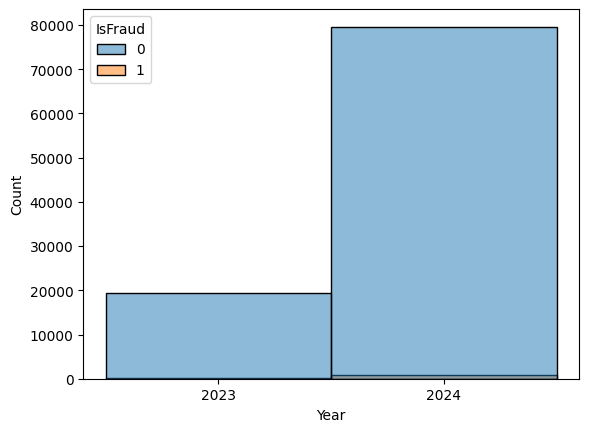

In [13]:
# Time for exploration
# Let us visually show through increasing disaggregation the fraud occurrences through the time dimensions
# First let's check out the data distribution
# Visualising the Amount data on a histogram
sns.histplot(data=df, x=df["Year"], discrete= True , hue="IsFraud") # Add discrete = True so that Seaborn doesn't treat it as a continuous variable
plt.xticks(df.Year.unique())
plt.show()

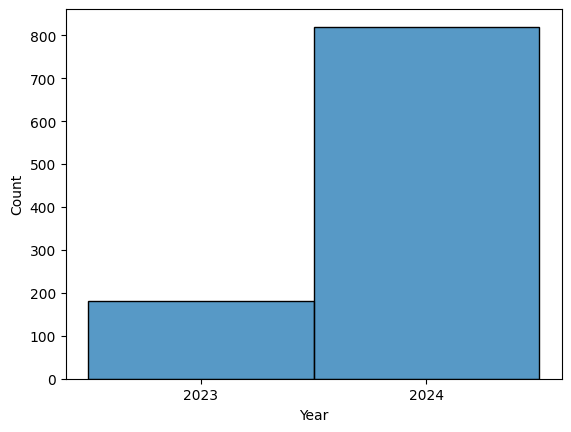

In [14]:
# We already have a data imbalance between the two years. We have far more data in 2024 than in 2023.
# Let's see the same data but with just fraud occurrences

sns.histplot(data=df[df['IsFraud']==1], x=df[df['IsFraud']==1]["Year"], discrete= True) # Add discrete = True so that Seaborn doesn't treat it as a continuous variable
plt.xticks(df.Year.unique())
plt.show()


In [15]:
# So essentially due to the increased representation of 2024, it is more likely to be biased to occurrences in 2024.
# Possible treatments https://medium.com/pythons-gurus/how-to-handle-imbalanced-time-series-data-c4a2202e7dfd


<Axes: xlabel='month', ylabel='Count'>

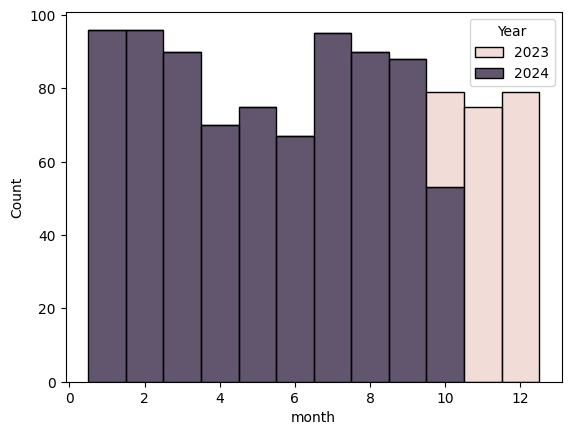

In [16]:
sns.histplot(data=df[df['IsFraud']==1], x=df[df['IsFraud']==1]["month"], hue = df["Year"], discrete= True, multiple='stack') # Add discrete = True so that Seaborn doesn't treat it as a continuous variable
#plt.xticks(df[df['IsFraud']==1].Month.unique())
#plt.show()

In [17]:
# Not only do we have underrepresensation for 2023, but also an incomplete year.
# But there seems to be some seasonality to the data with activity lulling in the autumn and spring months, and spiking in winter and summer months
# Let's investigate the patterns by day

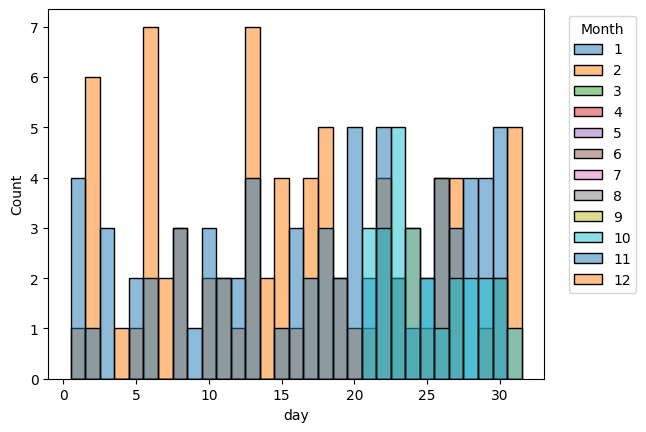

In [18]:
palette = sns.color_palette("tab10", 12)
ax = sns.histplot(data=df[(df['IsFraud']==1) & (df['Year']==2023)], 
             x=df[(df['IsFraud']==1) & (df['Year']==2023)]["day"], hue=df['month'], palette = palette, discrete= True) # specify through matpot instead
sns.move_legend(ax, "upper right", bbox_to_anchor=(1.2, 1), title='Month')
plt.show()

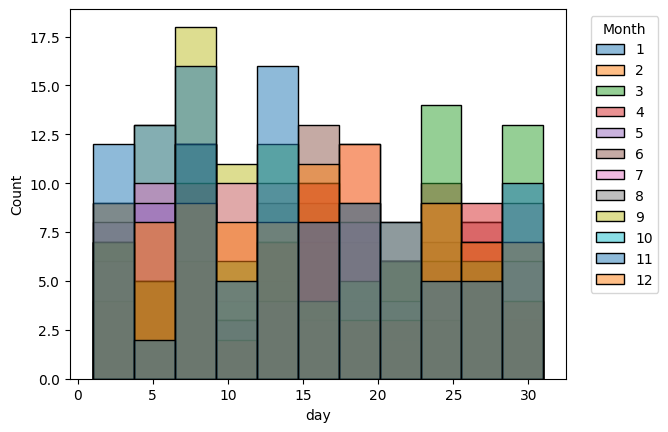

In [19]:
palette = sns.color_palette("tab10", 12)
ax = sns.histplot(data=df[(df['IsFraud']==1) & (df['Year']==2024)], 
             x=df[(df['IsFraud']==1) & (df['Year']==2024)]["day"], hue=df['month'], palette = palette) # specify through matpot instead
sns.move_legend(ax, "upper right", bbox_to_anchor=(1.2, 1), title='Month')
plt.show()

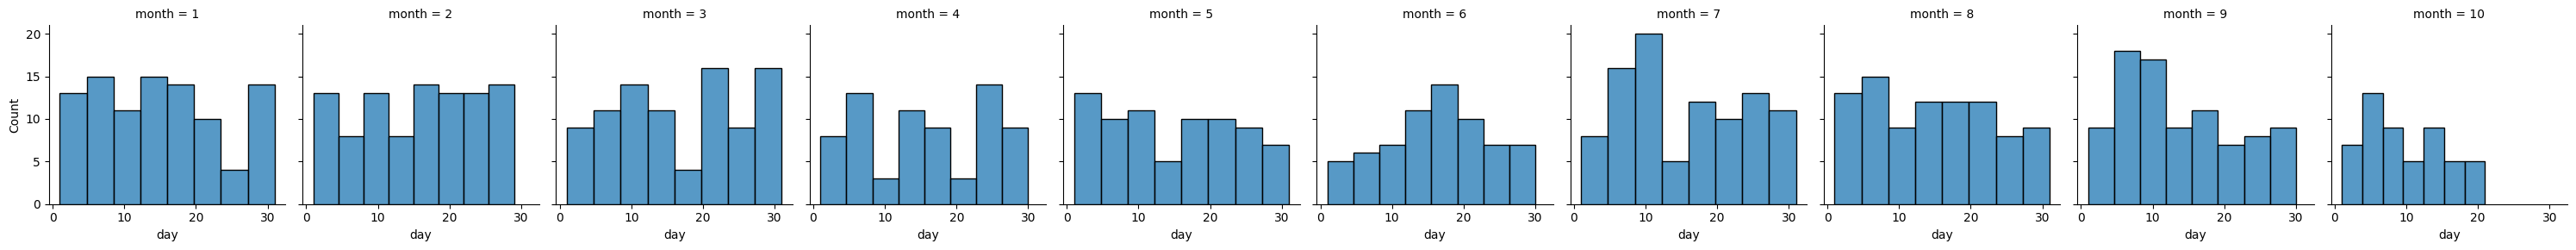

In [20]:
g = sns.FacetGrid(df[(df['IsFraud']==1) & (df['Year']==2024)], col='month')
g.map(sns.histplot, "day")

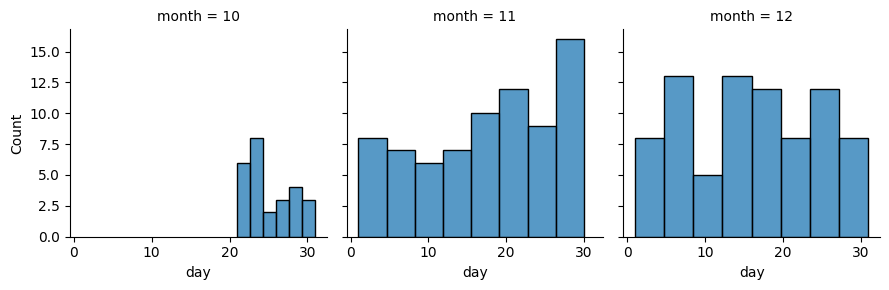

In [21]:
g = sns.FacetGrid(df[(df['IsFraud']==1) & (df['Year']==2023)], col='month')
g.map(sns.histplot, "day")


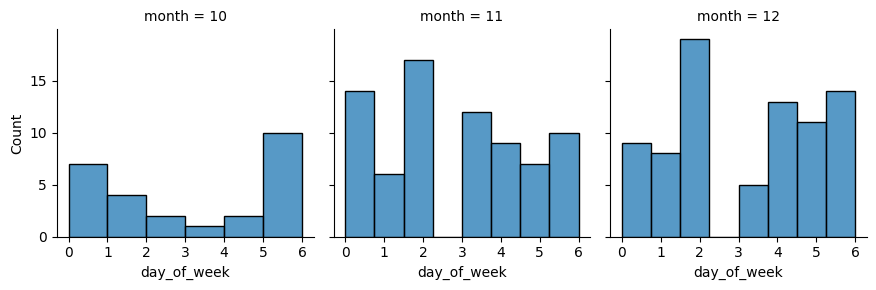

In [22]:
# There does seem to be some variability in terms of month/ day on which fraudulent transactions occur.
#Let's see how this is based on the day of the week
g = sns.FacetGrid(df[(df['IsFraud']==1) & (df['Year']==2023)], col='month')
g.map(sns.histplot, "day_of_week")
plt.xticks(df.day_of_week.unique())
plt.show()


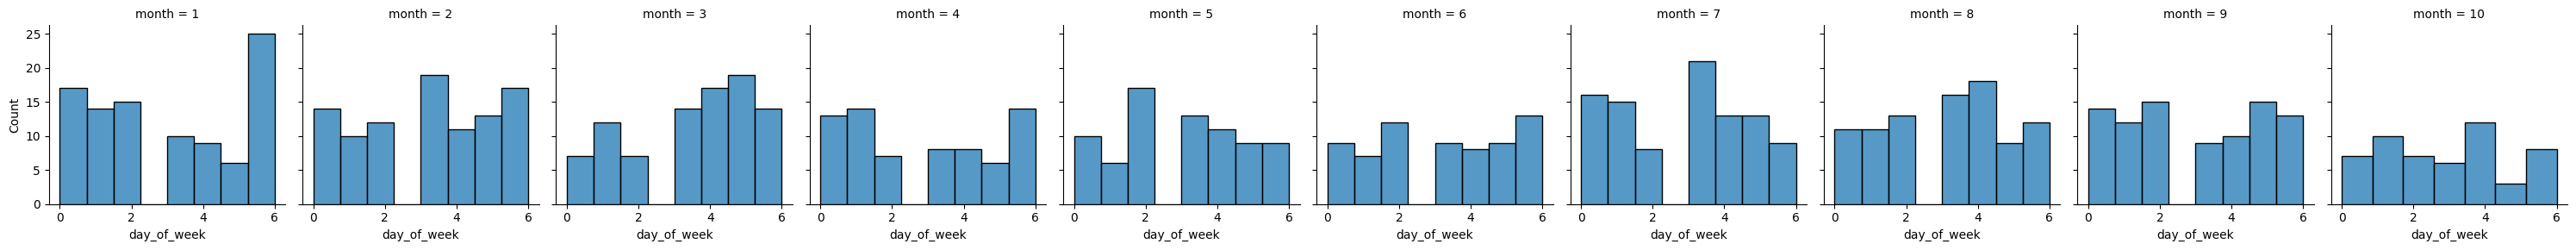

In [23]:
g = sns.FacetGrid(df[(df['IsFraud']==1) & (df['Year']==2024)], col='month')
g.map(sns.histplot, "day_of_week")

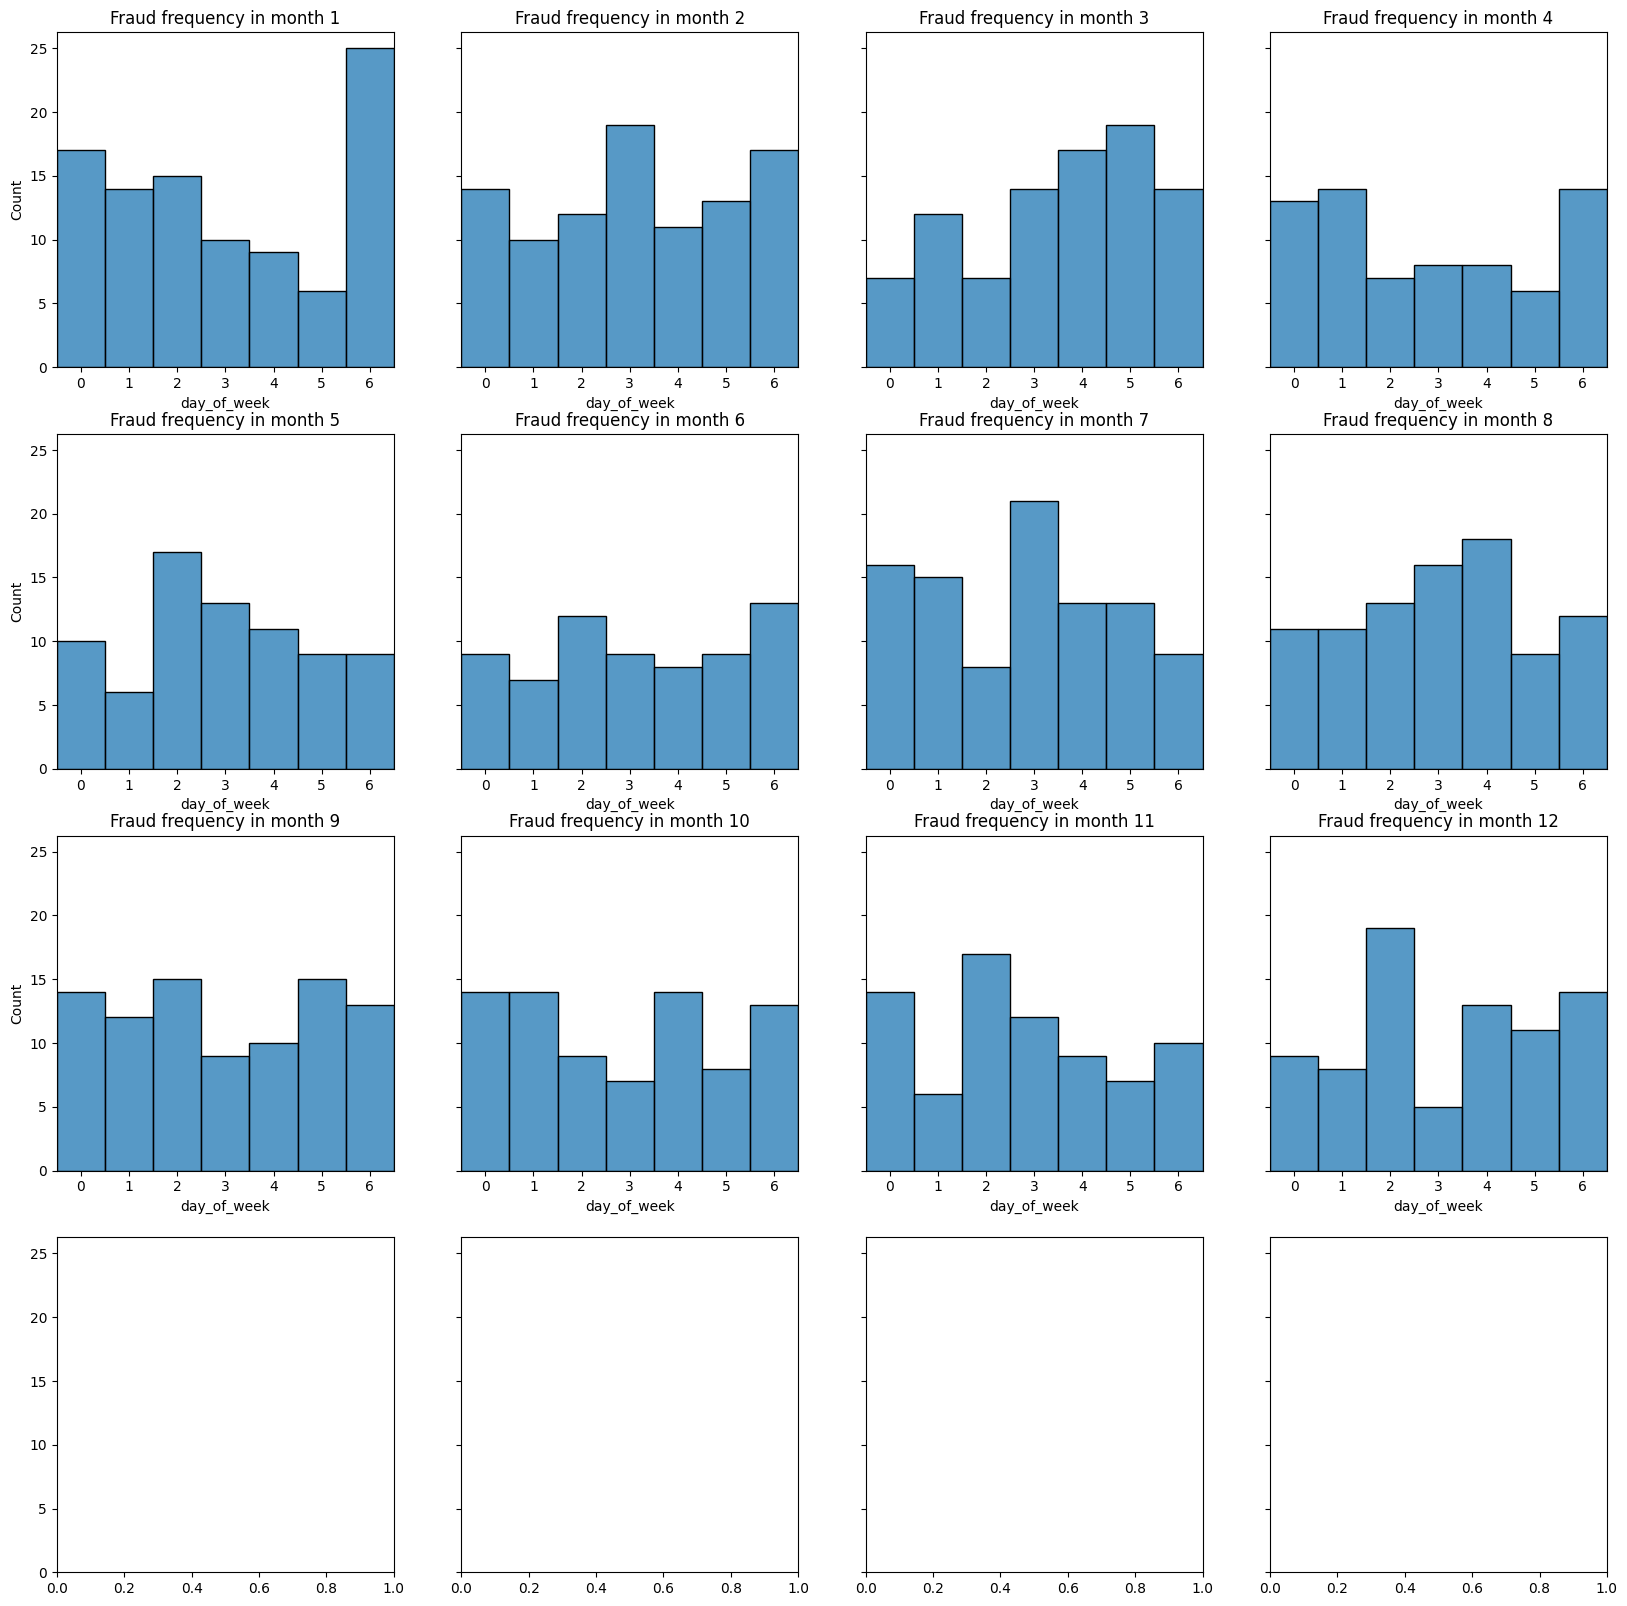

In [24]:
fig, axes = plt.subplots(4, 4, figsize=(20, 20), sharey=True)

mask_base = (df['IsFraud'] == 1) 
bin_edges = np.arange(-0.5, 7.5, 1)  # centers at 0..6

for i, month in enumerate(range(1, 13)):   # months 1..12; adjust if your months are 0..11
    ax = axes.flat[i]
    subset = df[mask_base & (df['month'] == month)]
    
    if len(subset) == 0:
        ax.set_title(f"Fraud frequency in month {month} (no data)")
        ax.set_xticks(range(7))
        ax.set_xlim(-0.5, 6.5)
        continue

    sns.histplot(
        data=subset,
        x="day_of_week",
        bins=bin_edges,
        discrete=True,
        stat="count",
        ax=ax
    )
    ax.set_title(f"Fraud frequency in month {month}")
    ax.set_xticks(range(7))
    ax.set_xlim(-0.5, 6.5)

In [25]:
# As previously identified, there seems to be some seasonality where the day on which fraudulent transactions most often occur changing on the season.
# In winter, they mostly seem to take place in the middle of the week, whereas in spring on the weekends.
# Here we could add some risk criterion based on month/day combination.

In [26]:
# What about the time?
# Is there a particular time of day where fraudulent transactions tend to happen?
# Let's take a look at our overall data

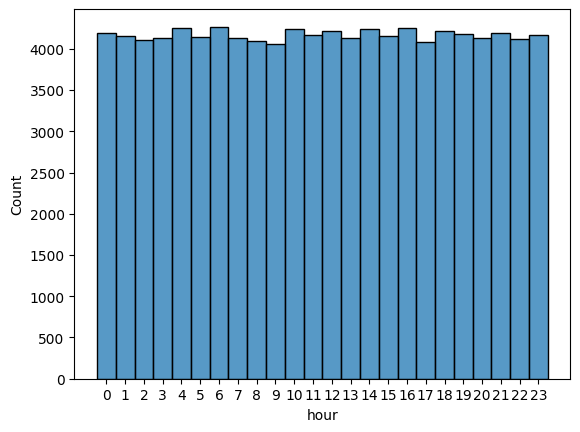

In [30]:
sns.histplot(data=df, x=df["hour"], discrete= True) # Add discrete = True so that Seaborn doesn't treat it as a continuous variable
plt.xticks(df.hour.unique())
plt.show()

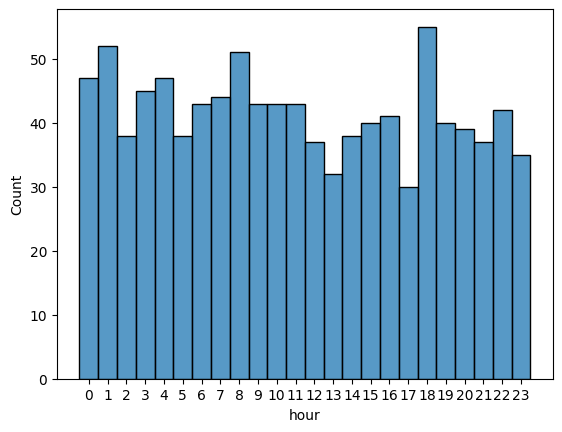

In [43]:
# The data seems to be evenly spread over the hours
# How does it look like when we just look at fraudulent data?
sns.histplot(data=df[df['IsFraud']==1], x="hour", bins=100, discrete= True) # Add discrete = True so that Seaborn doesn't treat it as a continuous variable
plt.xticks(df.hour.unique())
plt.show()

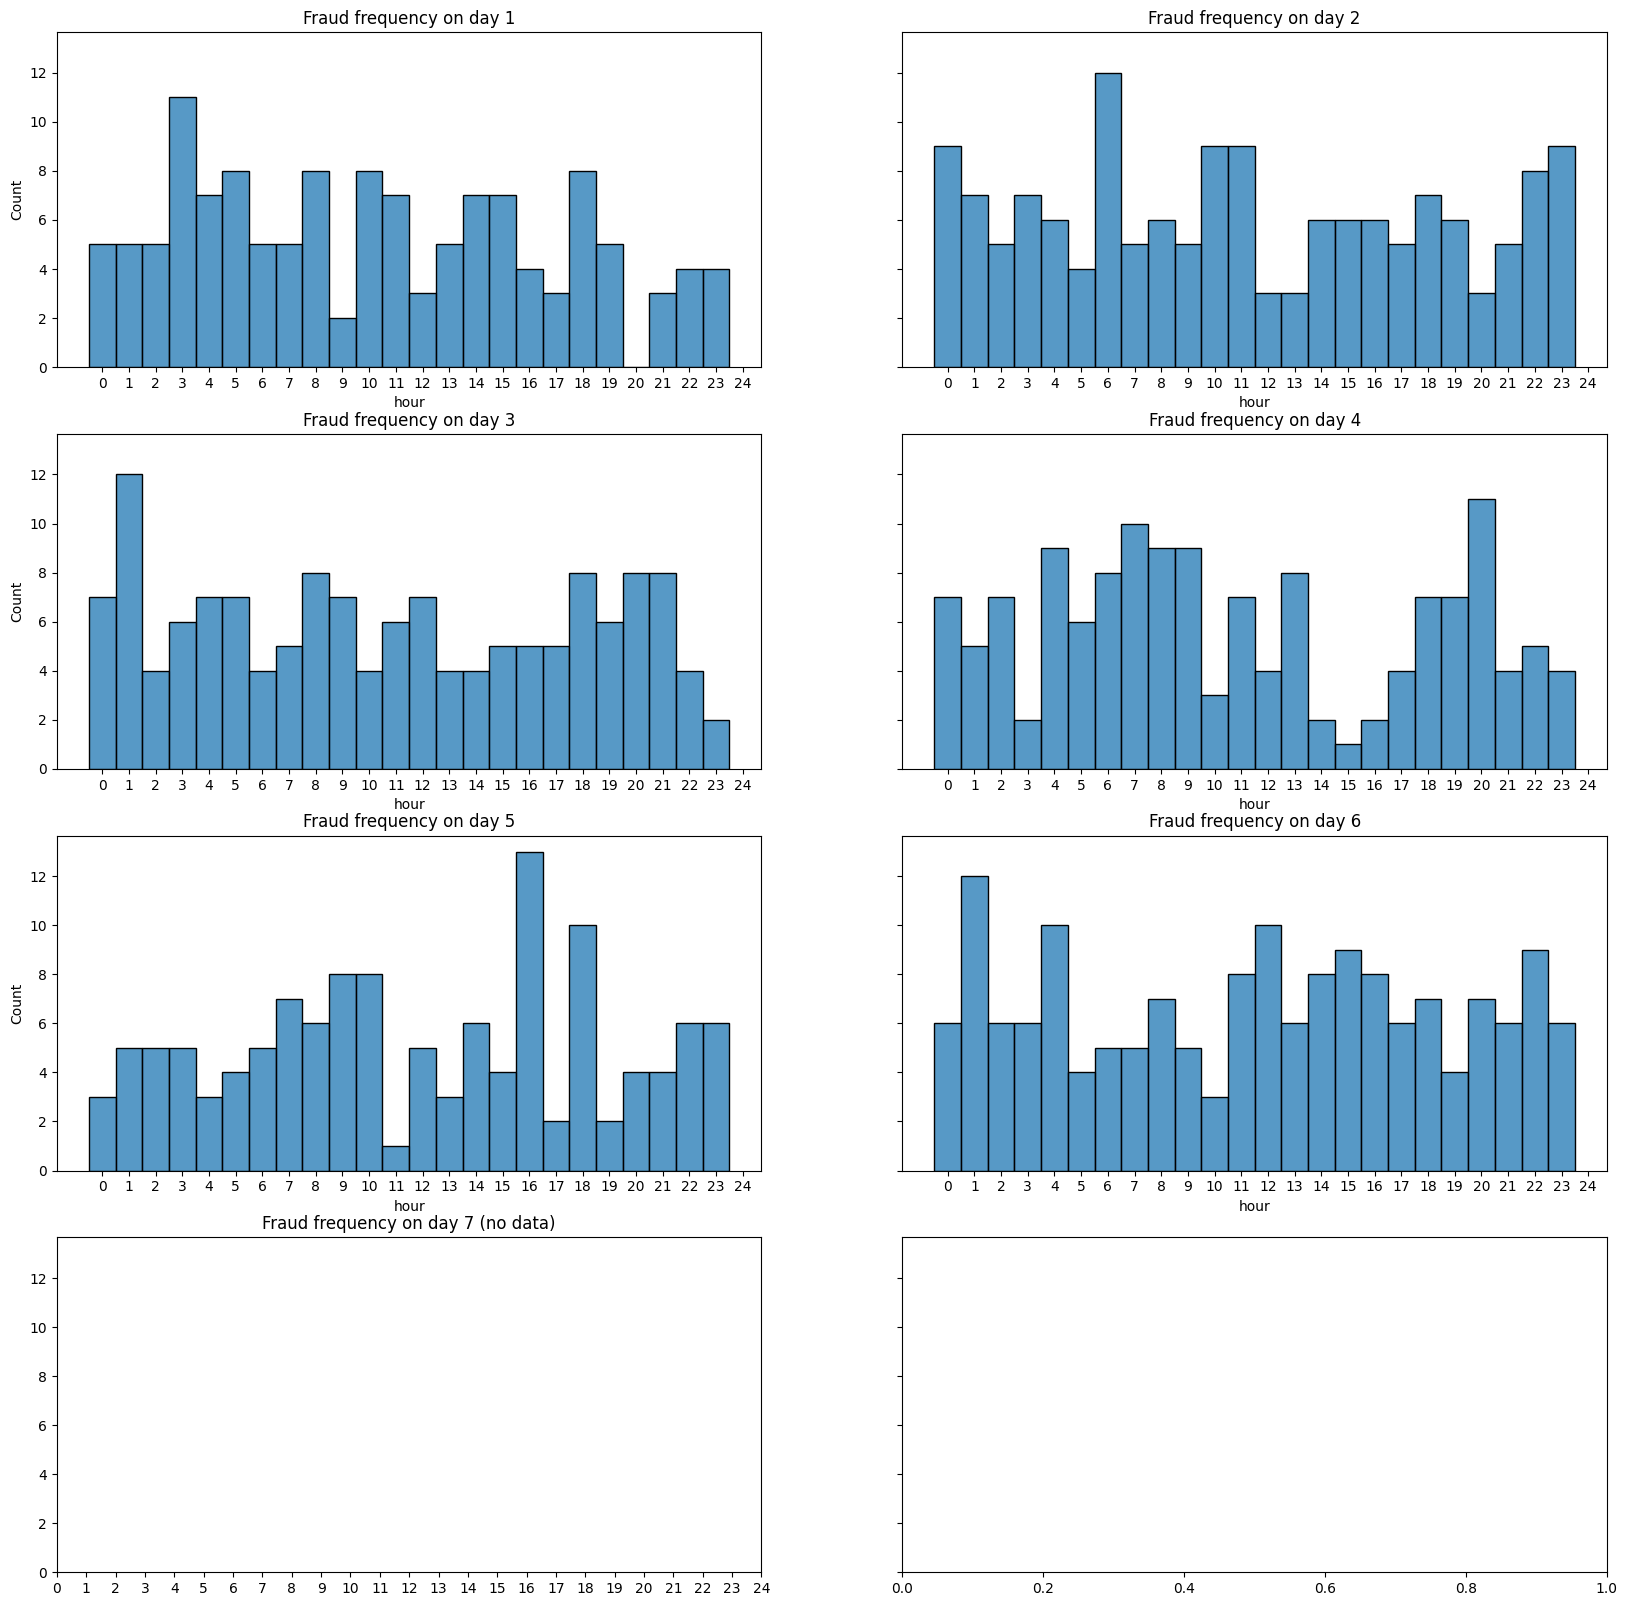

In [52]:
fig, axes = plt.subplots(4, 2, figsize=(20, 20), sharey=True)

mask_base = df[df['IsFraud'] == 1] 

for i, day in enumerate(range(1, 8)): 
    ax = axes.flat[i]
    subset = mask_base[mask_base['day_of_week'] == day]
    
    if len(subset) == 0:
        ax.set_title(f"Fraud frequency on day {day} (no data)")
        ax.set_xticks(range(25))
        #ax.set_xlim(-0.5, 6.5)
        continue

    sns.histplot(
        data=subset,
        x="hour",
        discrete=True,
        stat="count",
        ax=ax
    )
    ax.set_title(f"Fraud frequency on day {day}")
    ax.set_xticks(range(25))
    #ax.set_xlim(-0.5, 6.5)

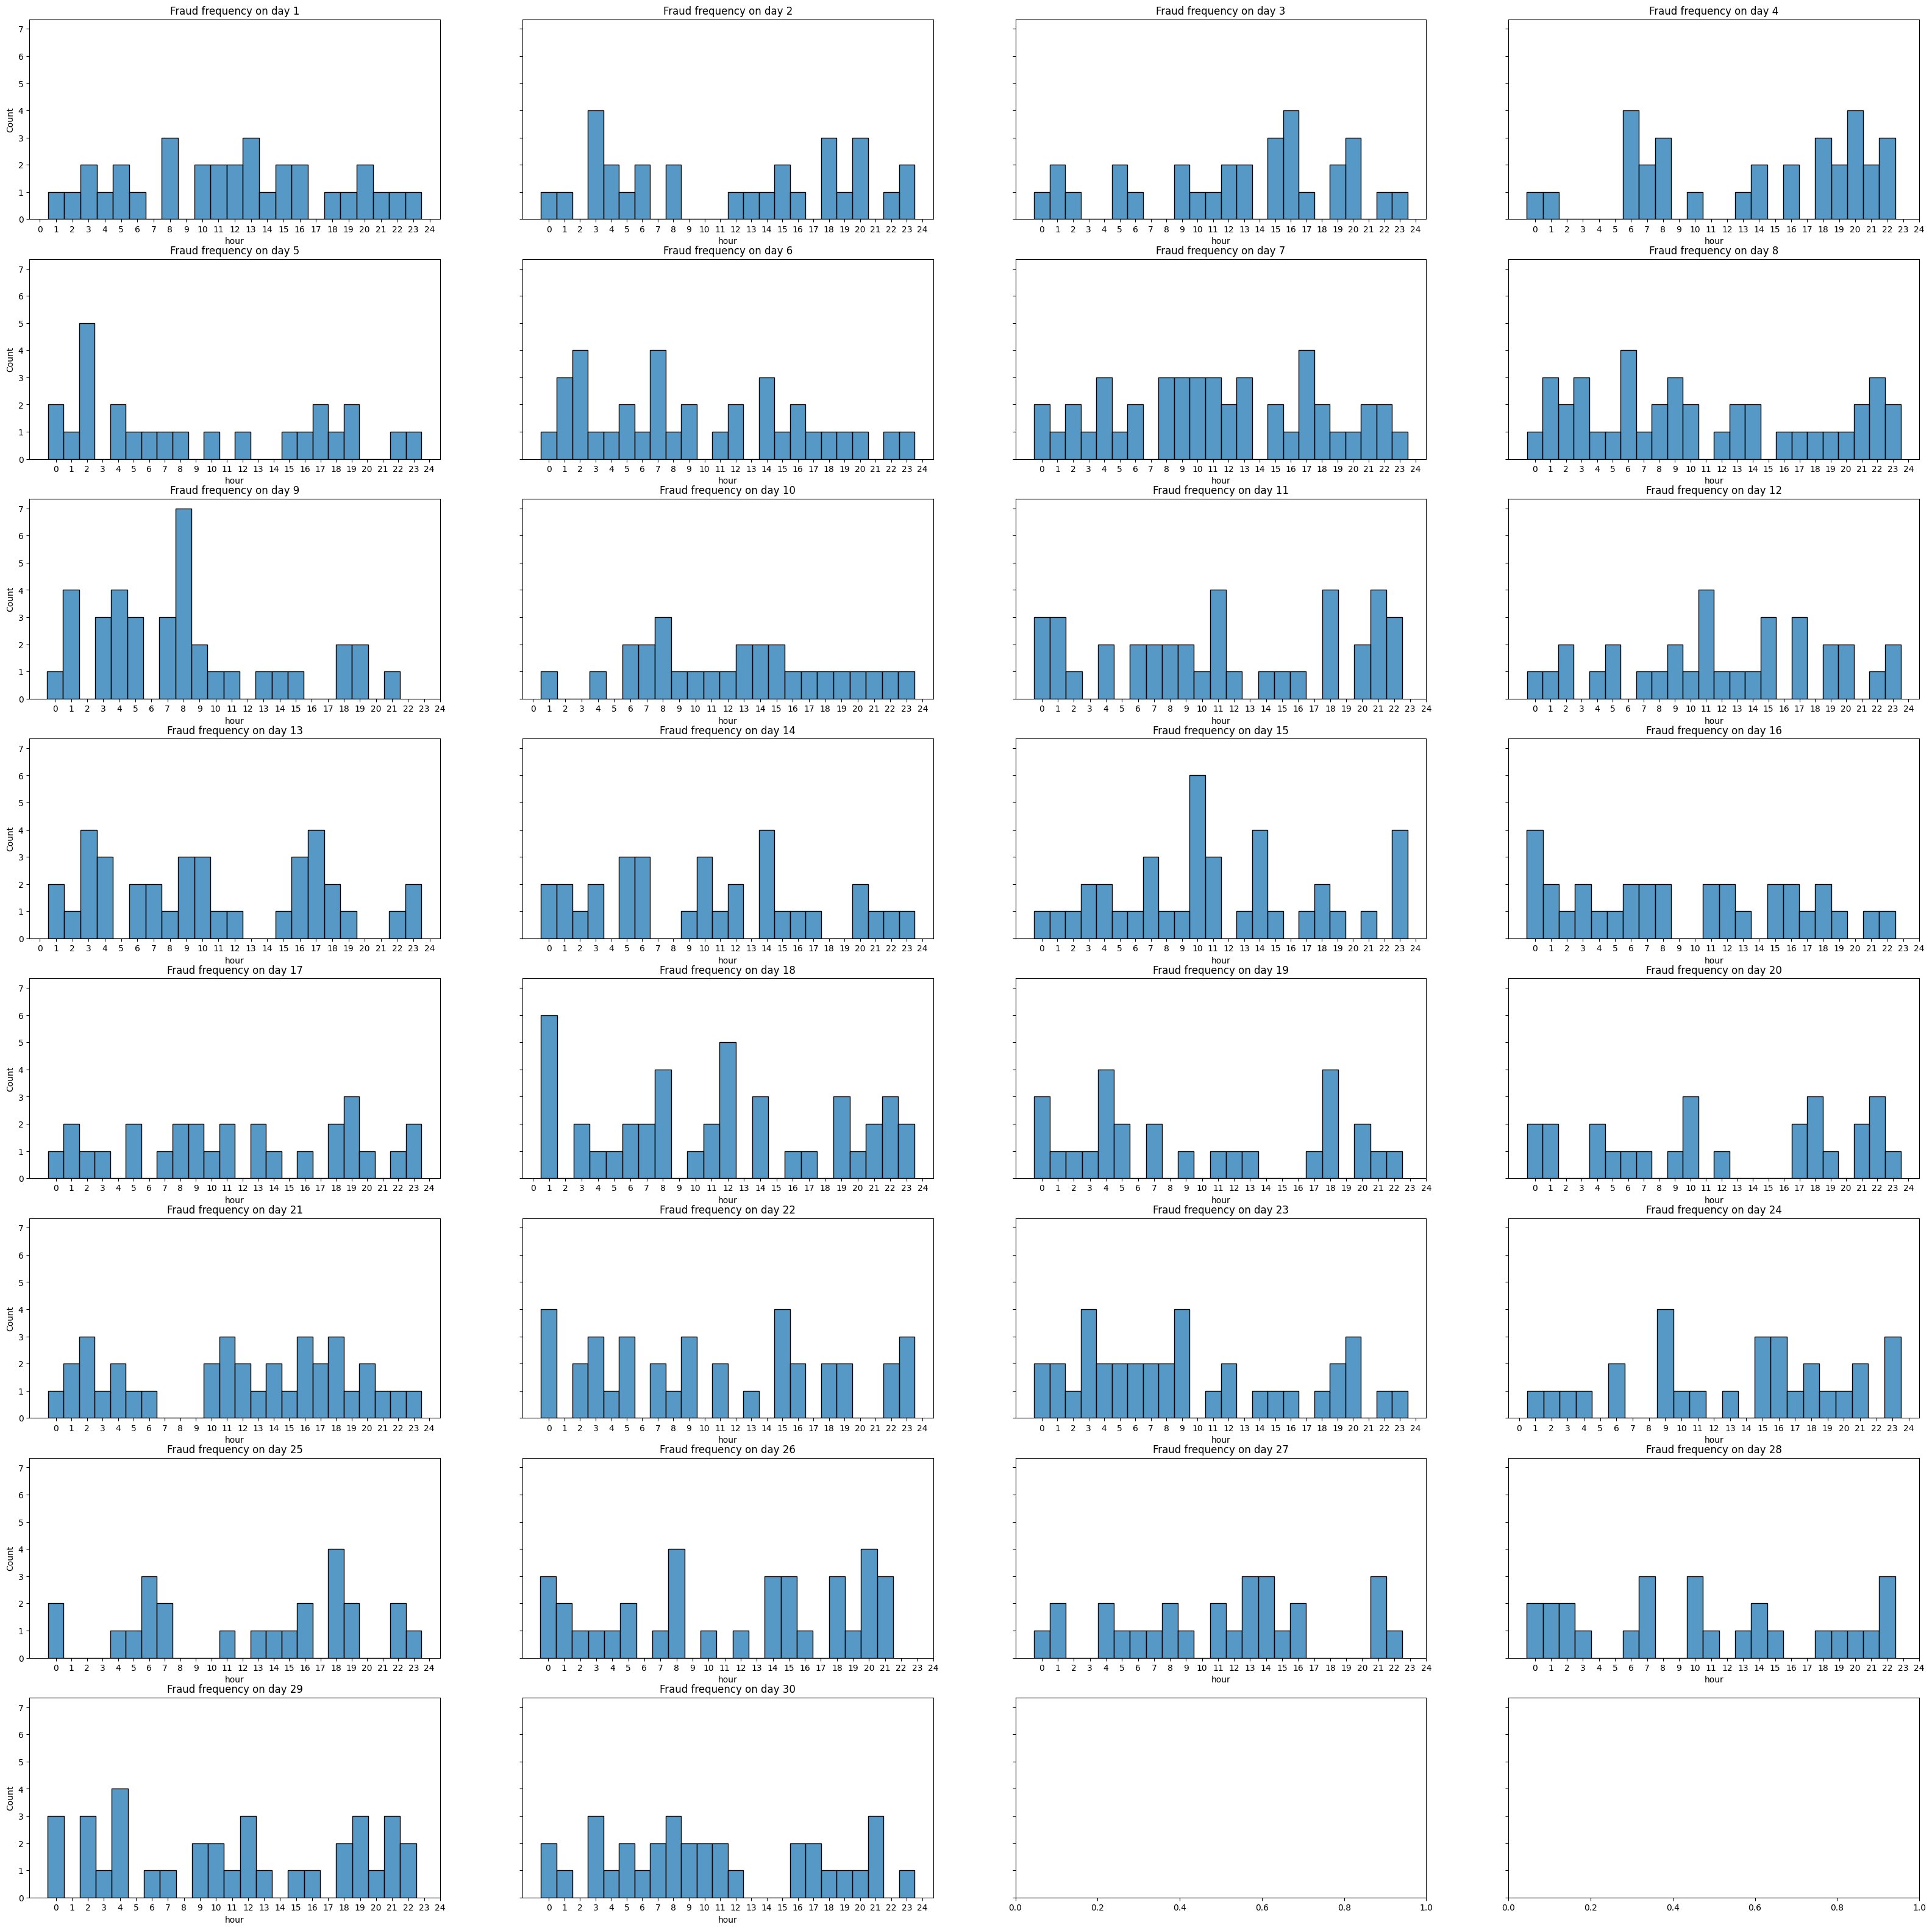

In [54]:
# There seems to be some dependence between the day and the time of day when fraud occurs.
# How does it look within the month? Does it change depending on the time of the month?


fig, axes = plt.subplots(8, 4, figsize=(40, 40), sharey=True)

mask_base = df[df['IsFraud'] == 1] 

for i, day in enumerate(range(1, 31)): 
    ax = axes.flat[i]
    subset = mask_base[mask_base['day'] == day]
    
    if len(subset) == 0:
        ax.set_title(f"Fraud frequency on day {day} (no data)")
        ax.set_xticks(range(25))
        #ax.set_xlim(-0.5, 6.5)
        continue

    sns.histplot(
        data=subset,
        x="hour",
        discrete=True,
        stat="count",
        ax=ax
    )
    ax.set_title(f"Fraud frequency on day {day}")
    ax.set_xticks(range(25))
    #ax.set_xlim(-0.5, 6.5)


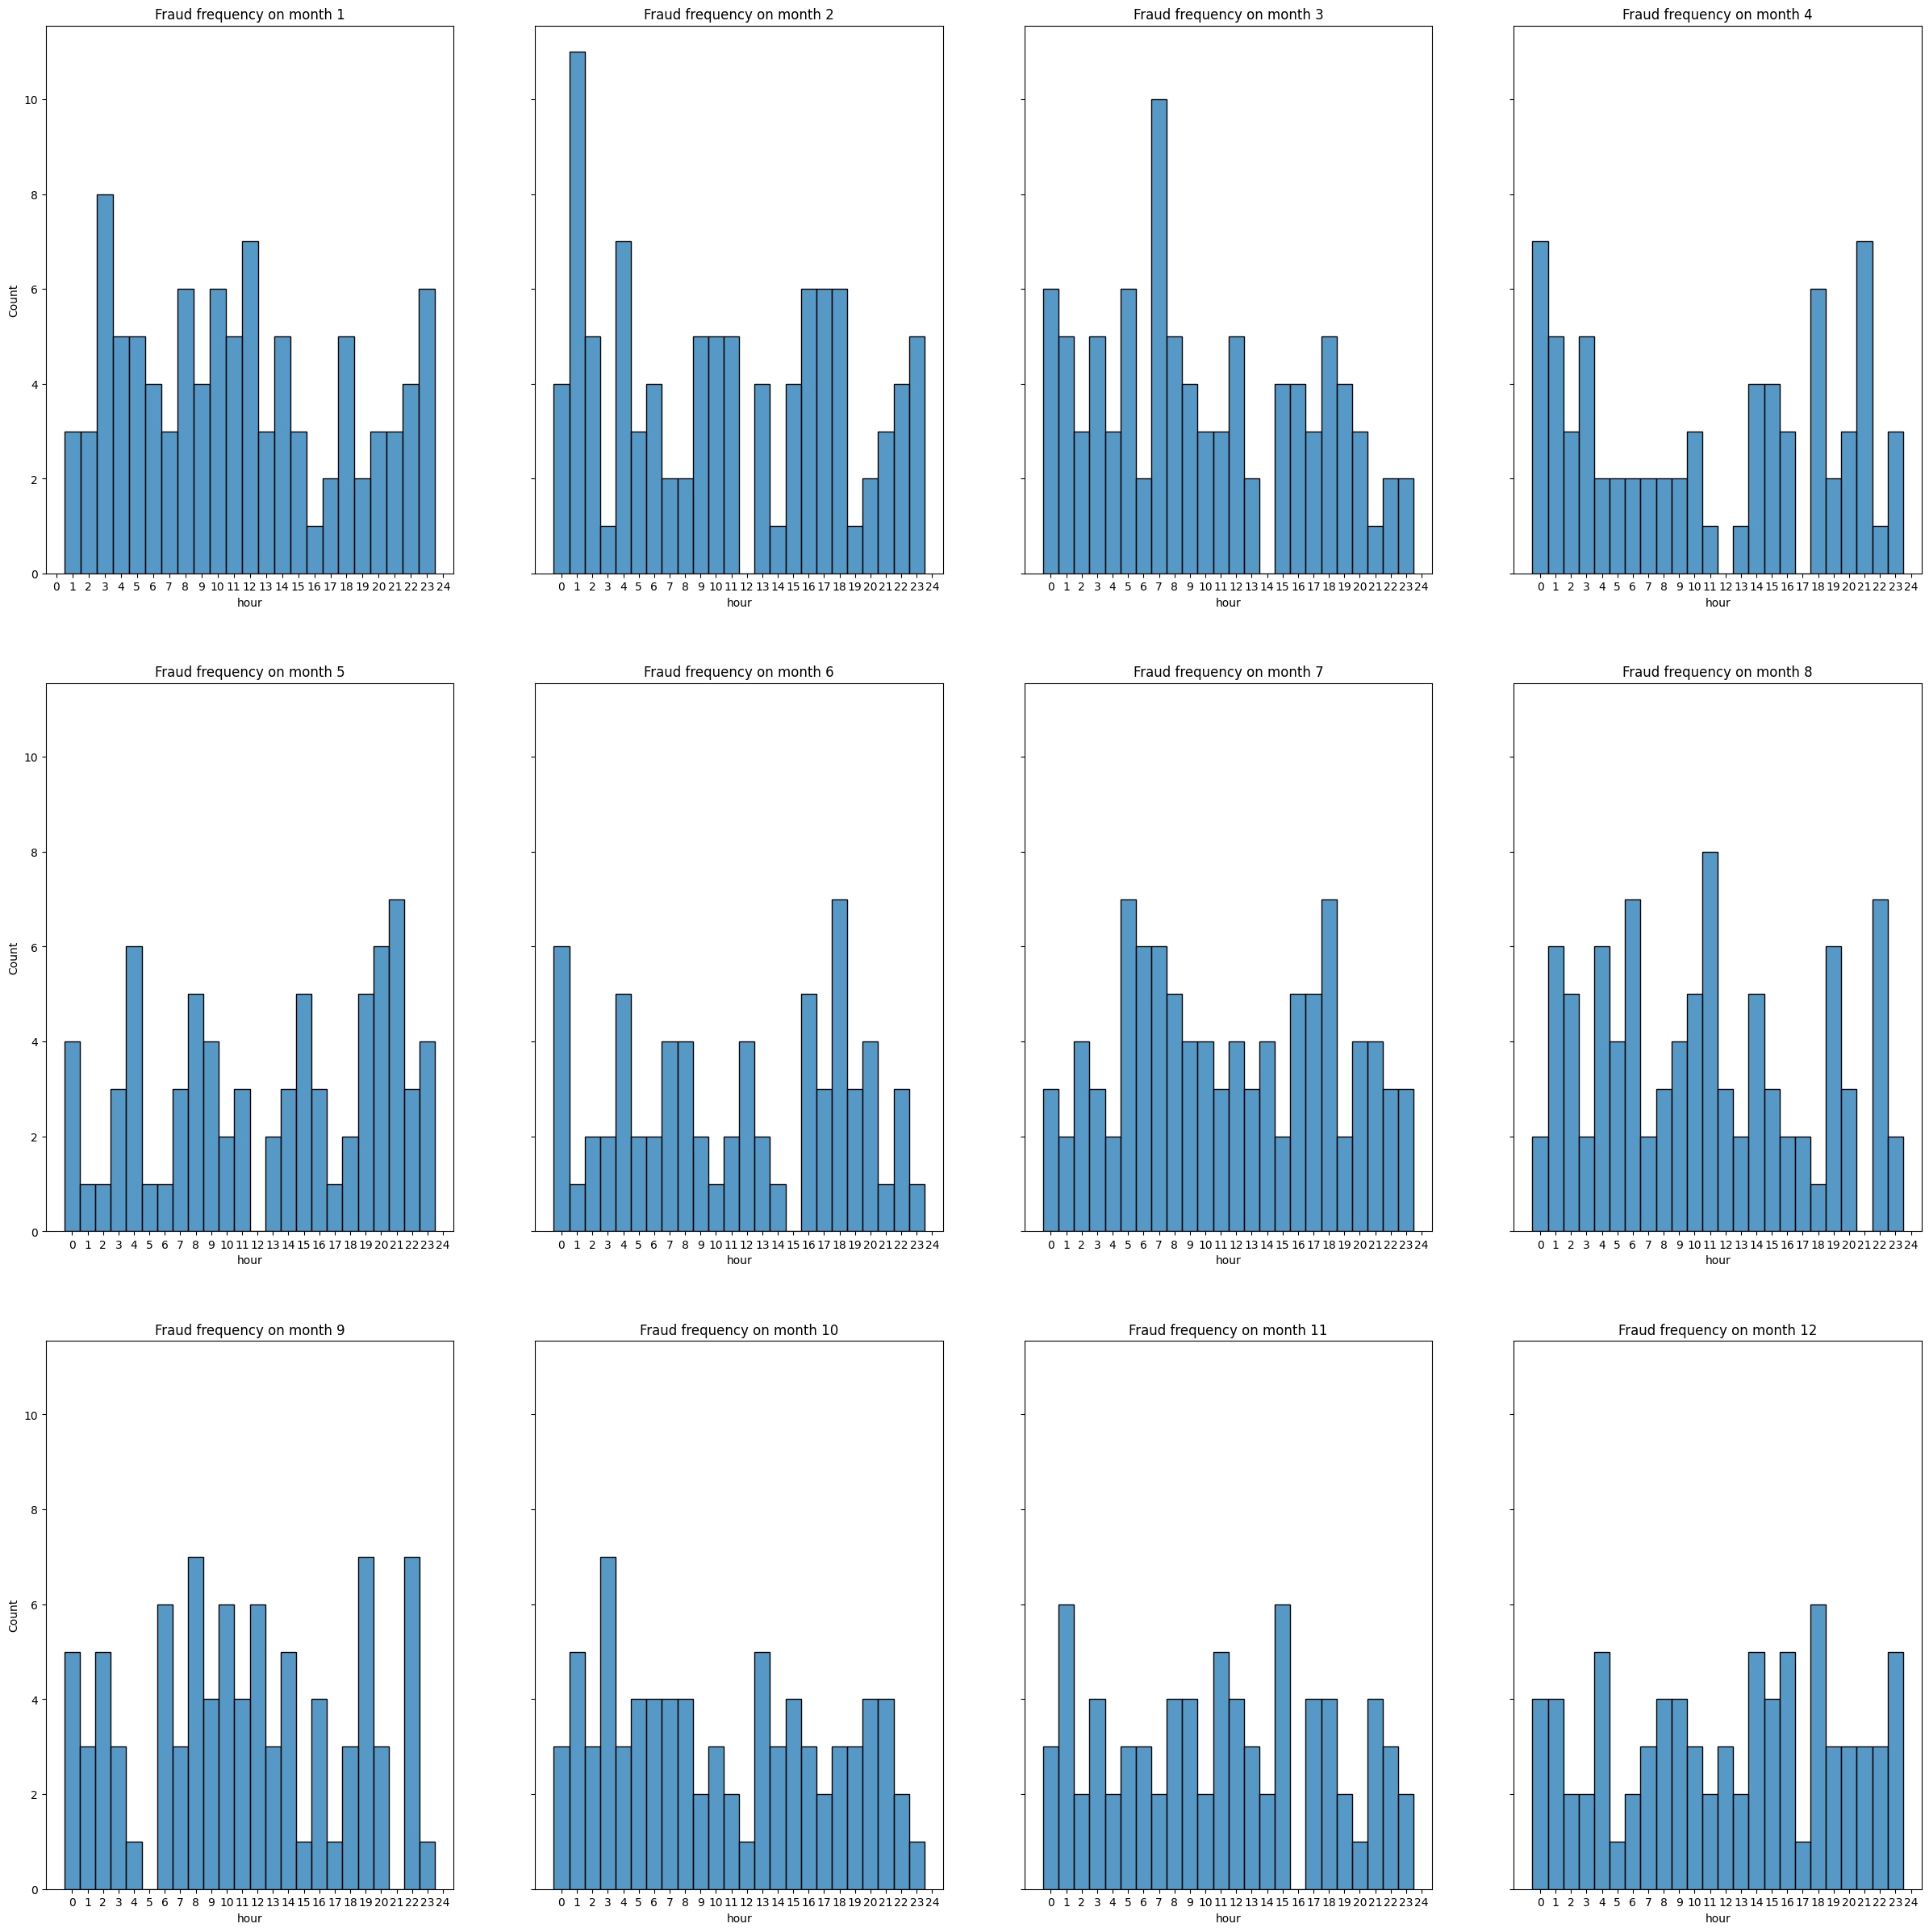

In [56]:
# Overall it looks fairly random, however, there are some specific days/time combination that have major spikes, such as day 18 at 1am.
# What about months, are there any particular months?

fig, axes = plt.subplots(3, 4, figsize=(30, 30), sharey=True)

mask_base = df[df['IsFraud'] == 1] 

for i, month in enumerate(range(1, 13)): 
    ax = axes.flat[i]
    subset = mask_base[mask_base['month'] == month]
    
    if len(subset) == 0:
        ax.set_title(f"Fraud frequency on month {month} (no data)")
        ax.set_xticks(range(25))
        #ax.set_xlim(-0.5, 6.5)
        continue

    sns.histplot(
        data=subset,
        x="hour",
        discrete=True,
        stat="count",
        ax=ax
    )
    ax.set_title(f"Fraud frequency on month {month}")
    ax.set_xticks(range(25))
    #ax.set_xlim(-0.5, 6.5)

In [ ]:
# There does seem to be some seasonality to it, with spikes occurring at some month-time combination.